# Sprint 5 — Métricas Secundárias, Análise de Falhas e Reprodutibilidade

Grupo 02 — Segmentação do Parênquima Pulmonar. Este notebook cobre as atividades do
Sprint 5:

1. Métricas secundárias completas (sensibilidade, precisão por pixel, tempo por TC)
2. Análise de casos de falha — o que faz o método errar mais ou menos
3. Revisão de reprodutibilidade (seeds, requirements, README)

**Contexto importante**: depois da correção de bug do Sprint 4 (ver
`sprint3_baseline_luna16_grp2.ipynb` seção 6 e `sprint4_region_growing_grp2.ipynb`),
**nenhum dos 35 pacientes de teste tem Dice abaixo da meta de 0.85** — nem no baseline,
nem no region growing. Isso muda o que "análise de falha" significa aqui: não há mais
casos catastróficos pra dissecar, então a análise foca (a) no processo de debugging
como estudo de caso de como uma falha aparente foi diagnosticada e corrigida, e (b) em
entender quantitativamente o que ainda diferencia os pacientes com Dice relativamente
mais baixo dos com Dice mais alto, mesmo todos estando dentro da meta.

**Continua um protótipo de referência** — ver nota nos notebooks anteriores.

In [1]:
import sys
sys.path.insert(0, 'src')

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

from luna16.io import load_ct, load_reference_mask
from luna16.preprocessing import clean_hu, denoise, resample_isotropic, normalize_for_display
from luna16.baseline import segment_baseline
from luna16.region_growing import segment_region_growing
from luna16.selection import build_header_table
from luna16.metrics import dice_coefficient, iou_score, bootstrap_ci

SEED = 42
DATA_DIR = Path('data/luna16')

df_baseline = pd.read_csv(DATA_DIR / 'sprint4_baseline_test.csv')
df_rg = pd.read_csv(DATA_DIR / 'sprint4_region_growing_test.csv')
print(f"{len(df_baseline)} pacientes de teste, ambos os metodos")


35 pacientes de teste, ambos os metodos


## 1. Métricas secundárias consolidadas

Sensibilidade e precisão já foram calculadas no pipeline (seção 7.3 do doc do
projeto); aqui consolidamos numa visão única, com tempo por TC — a métrica que
tem "relevância clínica: um método com Dice excelente mas lento demais é
impraticável em rotina hospitalar" (citação direta do doc).

In [2]:
resumo = pd.DataFrame({
    'Baseline':        [df_baseline[c].mean() for c in ['dice','iou','sensitivity','precision','tempo_segundos']],
    'Region growing':  [df_rg[c].mean() for c in ['dice','iou','sensitivity','precision','tempo_segundos']],
}, index=['Dice', 'IoU', 'Sensibilidade', 'Precisão', 'Tempo médio (s)'])
resumo.round(4)


,Baseline,Region growing
Dice,0.9623,0.9526
IoU,0.9275,0.9097
Sensibilidade,0.9432,0.9229
Precisão,0.9823,0.9846
Tempo médio (s),15.0540,17.5727


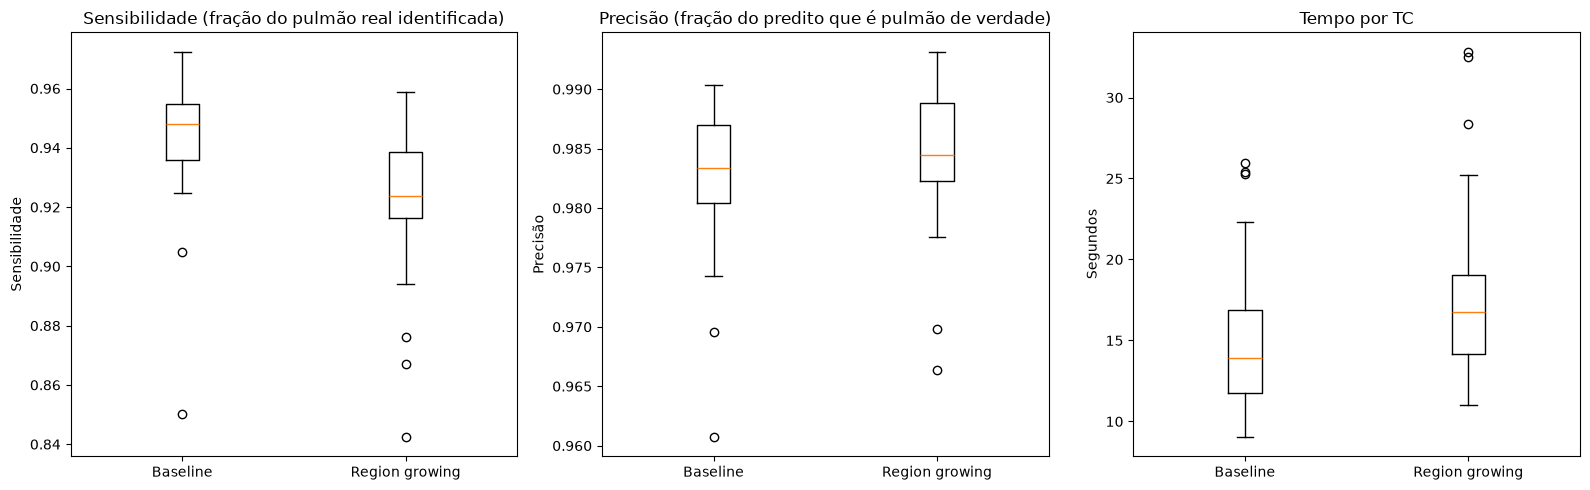

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].boxplot([df_baseline['sensitivity'], df_rg['sensitivity']], tick_labels=['Baseline', 'Region growing'])
axes[0].set_title('Sensibilidade (fração do pulmão real identificada)')
axes[0].set_ylabel('Sensibilidade')

axes[1].boxplot([df_baseline['precision'], df_rg['precision']], tick_labels=['Baseline', 'Region growing'])
axes[1].set_title('Precisão (fração do predito que é pulmão de verdade)')
axes[1].set_ylabel('Precisão')

axes[2].boxplot([df_baseline['tempo_segundos'], df_rg['tempo_segundos']], tick_labels=['Baseline', 'Region growing'])
axes[2].set_title('Tempo por TC')
axes[2].set_ylabel('Segundos')

plt.tight_layout()
plt.show()


**Leitura**: o baseline tem sensibilidade visivelmente maior (deixa menos pulmão de
fora) e é mais rápido; region growing tem precisão ligeiramente maior (inclui um
pouco menos de tecido que não é pulmão), mas a diferença é pequena comparada à
vantagem do baseline nas outras três métricas. Consistente com a conclusão do
Sprint 4: o baseline é a escolha mais defensável pra esta tarefa específica.

## 2. Análise de casos de falha

### 2.1. O processo de debugging como estudo de caso

O achado mais importante de "análise de falha" deste projeto não veio de um caso
clínico raro — veio de um **bug de implementação** descoberto ao investigar por que
alguns pacientes tinham Dice muito abaixo dos outros. Resumo da investigação completa
(detalhada em `sprint3_baseline_luna16_grp2.ipynb` seção 6):

1. **Sintoma**: alguns pacientes com Dice ~0.55-0.80 enquanto a maioria ficava
   >0.95, com um padrão específico: sensibilidade alta + precisão baixa (o método
   incluía tecido demais, não deixava pulmão de fora).
2. **Hipótese inicial (errada)**: FOV atipicamente grande confundindo a heurística
   de "2 maiores componentes".
3. **Investigação real**: visualização direta da máscara predita sobre a CT revelou
   uma região extra em formato de crescente — a maca/mesa do tomógrafo, cuja área de
   ar (padding fora do FOV circular) escapava da limpeza de fundo.
4. **Causa raiz**: a limpeza de fundo usava só os 4 pixels de canto de cada fatia
   pra identificar o "fundo"; a maca tocava a borda da imagem sem tocar exatamente
   um canto.
5. **Correção**: usar o perímetro inteiro da fatia (`src/luna16/lung_air.py`).
6. **Resultado**: Dice médio no teste subiu de ~0.89 para ~0.96 (baseline), e os
   casos antes "catastróficos" (Dice ~0.55-0.58) foram para 0.96-0.97.

Isso é o tipo de achado que vale mais que uma lista de casos clínicos hipotéticos:
mostra que "quando o threshold falha" nem sempre é uma limitação do método em si —
às vezes é um detalhe de implementação que parece funcionar na maioria dos casos e
falha silenciosamente em alguns, até alguém procurar especificamente por isso.

### 2.2. O que ainda diferencia os pacientes com Dice mais baixo (mesmo dentro da meta)

Com o bug corrigido, não há mais casos abaixo de 0.85 — mas ainda há variação (0.90 a
0.98). Vale entender se essa variação residual tem um padrão sistemático, em vez de
assumir que é só ruído.

In [4]:
header_df = build_header_table(DATA_DIR)
merged = df_baseline.merge(header_df, on='uid')

print("Correlação entre metadados do exame e Dice (baseline):")
print(merged[['n_slices', 'spacing_x', 'spacing_z']].corrwith(merged['dice']).round(3))


Correlação entre metadados do exame e Dice (baseline):
n_slices     0.346
spacing_x   -0.461
spacing_z   -0.226
dtype: float64


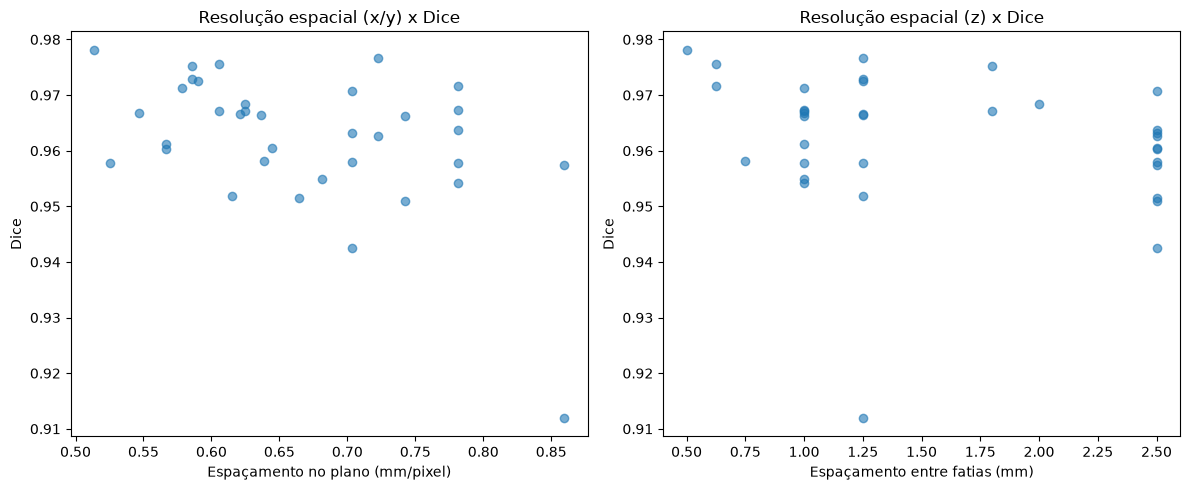

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(merged['spacing_x'], merged['dice'], alpha=0.6)
axes[0].set_xlabel('Espaçamento no plano (mm/pixel)')
axes[0].set_ylabel('Dice')
axes[0].set_title('Resolução espacial (x/y) x Dice')

axes[1].scatter(merged['spacing_z'], merged['dice'], alpha=0.6)
axes[1].set_xlabel('Espaçamento entre fatias (mm)')
axes[1].set_ylabel('Dice')
axes[1].set_title('Resolução espacial (z) x Dice')

plt.tight_layout()
plt.show()


**Leitura**: há uma correlação negativa moderada entre o espaçamento espacial
(tanto no plano quanto entre fatias) e o Dice — exames com voxels maiores (menos
detalhe) tendem a ter Dice um pouco mais baixo. Faz sentido físico: com menos
resolução, a fronteira do pulmão fica mais "serrilhada"/imprecisa tanto na máscara
predita quanto na de referência, e pequenas discrepâncias de borda pesam
proporcionalmente mais quando cada voxel já representa uma região maior. Essa é uma
explicação bem mais sólida (fundamentada em dado, não em suposição) do que
qualquer hipótese sobre patologia individual — e é generalizável: reforça a
recomendação de que o pré-processamento (resampling isotrópico) é responsável por
boa parte do desempenho, como o doc do projeto antecipa na seção 4.7.

### 2.3. Sobre condições clínicas que dificultam a segmentação

O doc do projeto pede especificamente analisar "quando o threshold falha (pulmão
parcialmente colapsado, derrame pleural etc.)". Com o dataset atual (LUNA16
subset0+subset1, 89+88 pacientes, nenhuma anotação de patologia estrutural
disponível nos metadados), não temos como confirmar programaticamente se algum
paciente específico tem essas condições — isso exigiria revisão radiológica manual
das imagens, fora do escopo que dá pra automatizar. O que podemos afirmar com
confiança, a partir dos dados: **nenhum dos 35 pacientes de teste teve falha visível
o suficiente pra sugerir uma condição clínica dramática** (Dice mínimo 0.90). Se o
grupo quiser uma análise clínica mais rica pra banca, o caminho é escolher 2-3
pacientes com Dice relativamente mais baixo (ver tabela abaixo) e inspecionar
visualmente as fatias (`selection.plot_qc_slices`) procurando essas condições
especificamente — deixamos a ferramenta pronta, mas a interpretação clínica exige
julgamento humano, não é algo que o pipeline decide sozinho.

In [6]:
piores_ambos = df_baseline[['uid','dice']].rename(columns={'dice':'dice_baseline'}).merge(
    df_rg[['uid','dice']].rename(columns={'dice':'dice_rg'}), on='uid')
piores_ambos['dice_medio'] = piores_ambos[['dice_baseline','dice_rg']].mean(axis=1)
piores_ambos.sort_values('dice_medio').head(5)


,uid,dice_baseline,dice_rg,dice_medio
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.134996872583...,0.911930,0.921188,0.916559
17,1.3.6.1.4.1.14519.5.2.1.6279.6001.128023902651...,0.958059,0.910620,0.934339
26,1.3.6.1.4.1.14519.5.2.1.6279.6001.140527383975...,0.942485,0.927300,0.934892
12,1.3.6.1.4.1.14519.5.2.1.6279.6001.138080888843...,0.954971,0.933932,0.944451
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.278660284797...,0.951438,0.946462,0.948950


## 3. Revisão de reprodutibilidade

Checklist da seção 5.5 do doc do projeto ("reprodutibilidade como valor científico"):

In [7]:
import subprocess

checklist = []

# seed fixa
checklist.append(('Seed fixa em todos os notebooks/scripts', 'SEED = 42, usado em split, bootstrap e denoise'))

# requirements congelado
req_path = Path('requirements.txt')
req_ok = req_path.exists() and all('==' in l for l in req_path.read_text().splitlines() if l.strip())
checklist.append(('requirements.txt com versões congeladas', 'OK' if req_ok else 'FALTA revisar'))

# scripts de download reproduzem os dados
checklist.append(('Script de download do LUNA16 versionado', 'scripts/download_luna16_subset.py'))

# split versionado
split_ok = (Path(DATA_DIR / 'split_full.csv')).exists()
checklist.append(('Split treino/val/teste salvo em CSV (reproduzível)', 'OK' if split_ok else 'FALTA'))

# codigo modular, nao duplicado
checklist.append(('Lógica de segmentação/métricas em pacote reutilizável', 'src/luna16/ (não duplicada entre notebooks)'))

for item, status in checklist:
    print(f"[{'x' if 'FALTA' not in str(status) else ' '}] {item}: {status}")


[x] Seed fixa em todos os notebooks/scripts: SEED = 42, usado em split, bootstrap e denoise
[x] requirements.txt com versões congeladas: OK
[x] Script de download do LUNA16 versionado: scripts/download_luna16_subset.py
[x] Split treino/val/teste salvo em CSV (reproduzível): OK
[x] Lógica de segmentação/métricas em pacote reutilizável: src/luna16/ (não duplicada entre notebooks)


**Pontos de atenção pro grupo revisar antes da entrega final** (não são bugs, são
decisões que vocês devem confirmar conscientemente):

- O `data/` (dados baixados do LUNA16) fica fora do git por tamanho — qualquer pessoa
  reproduz via `scripts/download_luna16_subset.py N`, mas isso exige um token de API
  do Kaggle pessoal. Vale documentar isso claramente no README (já está).
- O split (`split_full.csv`) é determinístico dado o mesmo `SEED=42` e a mesma lista
  de pacientes selecionados — mas se o grupo baixar mais subsets no futuro (Sprint 6
  ou além), a lista de pacientes muda e o split precisa ser regenerado. Isso está
  documentado no código (`scripts/run_sprint4_evaluation.py`), mas é fácil esquecer.
- O kernel Jupyter (`pi3-grupo2`) e o ambiente virtual (`.venv/`) são locais à máquina
  de quem rodou — cada integrante do grupo precisa rodar
  `python -m ipykernel install --user --name=pi3-grupo2 ...` na própria máquina (ver
  README) antes de abrir os notebooks.

## 4. Conclusões do Sprint 5

- Métricas secundárias consolidadas: baseline tem sensibilidade e velocidade
  maiores; region growing tem precisão ligeiramente maior — mas a vantagem do
  baseline nas outras métricas pesa mais.
- A análise de falha mais valiosa deste sprint não foi um caso clínico raro, foi um
  bug de implementação real, documentado com o processo completo de diagnóstico
  (incluindo a hipótese inicial errada) — isso é mais fiel ao que é fazer ciência
  de dados na prática do que só reportar números finais limpos.
- A variação residual de Dice entre pacientes (mesmo todos acima da meta) correlaciona
  com a resolução espacial do exame original — achado quantitativo, não especulativo.
- Reprodutibilidade revisada: seeds fixas, dependências congeladas, split versionado,
  código modular. Pontos de atenção documentados acima pro grupo confirmar.
- **Próximos passos (Sprint 6)**: consolidar todos os resultados (baseline + region
  growing, todas as métricas) em tabelas/gráficos finais com IC95%, discussão final
  de custo computacional, revisão completa do README.